## Logistic Regression - binary case
We will look on the classic IRIS data set, and construct a classifier for the setosa flower (class 0) based on sepal length (feature 0)


In [2]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
iris = load_iris()
print("size of data {}\nnames of columns {}\ntarget label size {}\nlabel names {}".format(iris.data.shape, iris.feature_names, iris.target.shape, iris.target_names))

size of data (150, 4)
names of columns ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target label size (150,)
label names ['setosa' 'versicolor' 'virginica']


## Pandas
Now we want to use pandas dataframes to explore the data a bit. Lets create a dataframe for the data and the labels and then join them together so we have everything in one spot.

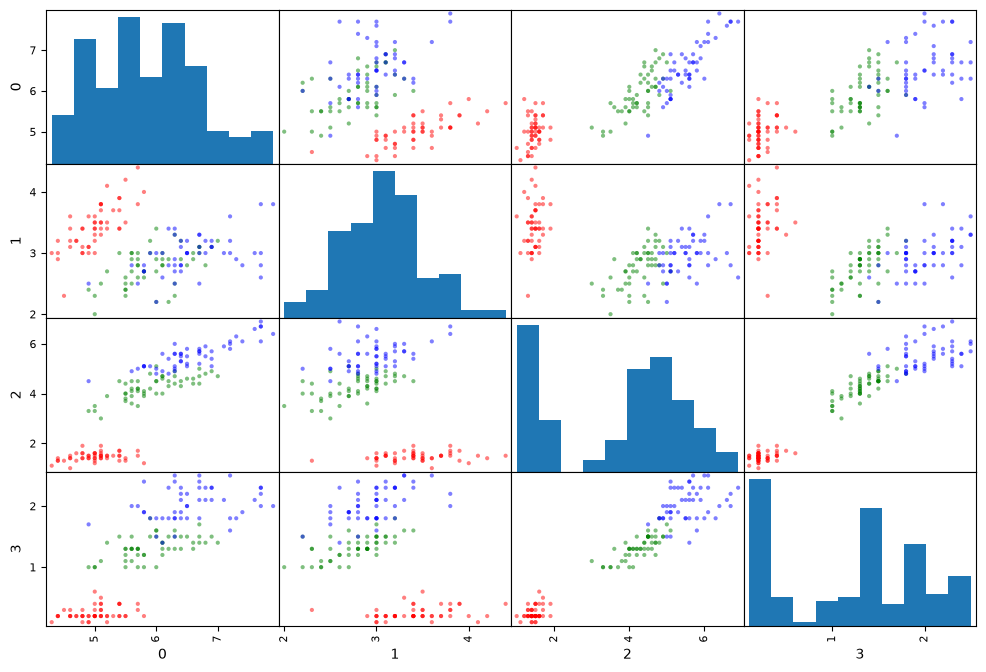

In [4]:
df=pd.DataFrame(iris.data)
colMap={0:"red",1:"green",2:"blue"}
cols=list(map(lambda x:colMap.get(x),iris.target))
scatter_matrix(df,  diagonal='hist',c=cols,figsize = (12,8))
fig1 = plt.gcf()
#from google.colab import files
#plt.savefig("plotiris.pdf")
#files.download("plotiris.pdf")



"""
0-3 here are the feature classes
rgb are the target classes


"""


In [23]:
from sklearn.linear_model import LogisticRegression
X = iris["data"][:,0:1].reshape(-1,1) # sepal length, takes all rows, but only first feature column (sepal len), rehape "-1" is just "as many as fits" 
row = X.reshape(1,-1)
y = (iris["target"] == 0).astype(int).reshape(-1,1)# y = 1 if Setosa
flattened_y = y.flatten()

logmodel = LogisticRegression(verbose=1)
np.ravel
logmodel.fit(X,flattened_y)

,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem

(np.float64(4.0), np.float64(8.0), np.float64(-0.02), np.float64(1.02))

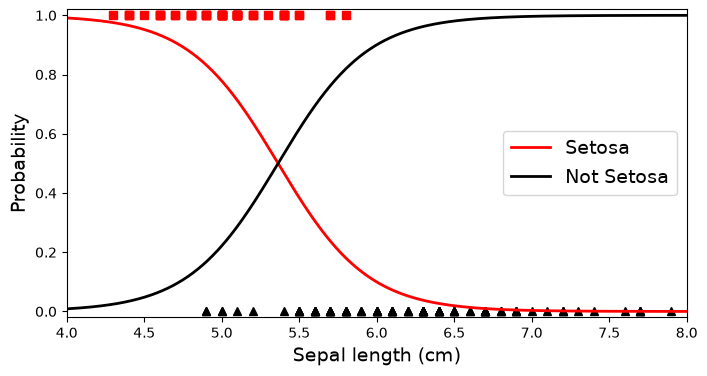

In [26]:
# Plot Setosa probability versus Sepal Length
Xnew = np.linspace(4,8,1000).reshape(-1,1)
yproba = logmodel.predict_proba(Xnew)

plt.figure(figsize=(8, 4))
plt.plot(X[y==1], y[y==1], "rs")
plt.plot(X[y==0], y[y==0], "k^")
plt.plot(Xnew,yproba[:,1],"r-",linewidth=2,label = "Setosa")
plt.plot(Xnew,1-yproba[:,1],"k-",linewidth=2,label = "Not Setosa")
plt.xlabel("Sepal length (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center right", fontsize=14)
plt.axis([4, 8, -0.02, 1.02])
#plt.savefig("plotiris2.pdf")
#files.download("plotiris2.pdf")